<a href="https://colab.research.google.com/github/urnotirisfeng/AI/blob/main/Visualisation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apprentissage Supervisé

# **EX1 Feature selection**

In [37]:
import pandas as pd
import numpy as np

## **EX 1-1**

In [38]:
file_path = "/content/credit.csv"
data = pd.read_csv(file_path)

print("Info：")
print(data.info())

# 查看前几行数据
print("\n5lines：")
print(data.head(5))

Info：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

5lines：
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male     

In [39]:
print ("Lost valeur :")
print (data.isnull().sum())

Lost valeur :
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [40]:
print("List name：")
print(data.columns)

List name：
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [41]:
from sklearn.preprocessing import LabelEncoder
# 数据处理

# 删除无用的ID列
if 'Loan_ID' in data.columns:
    data = data.drop(['Loan_ID'], axis=1)

# 数值型特征填补：使用中位数
numeric_cols = data.select_dtypes(include=[float, int]).columns
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

# 分类特征填补：使用众数
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# **只使用标签编码，保留原始列名**
label_encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

# 打印表头，验证是否保留原始列名
print("\n表头名称（保留原格式）：")
print(data.columns)


表头名称（保留原格式）：
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


<ipython-input-41-f4627d03092f>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
<ipython-input-41-f4627d03092f>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [42]:
from sklearn.model_selection import train_test_split
# 分离特征和目标变量
X = data.drop(columns=['Loan_Status'])
y = data['Loan_Status']

# 划分训练集和测试集
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTrain size:", train_X.shape, "Test size:", test_X.shape)


Train size: (491, 11) Test size: (123, 11)


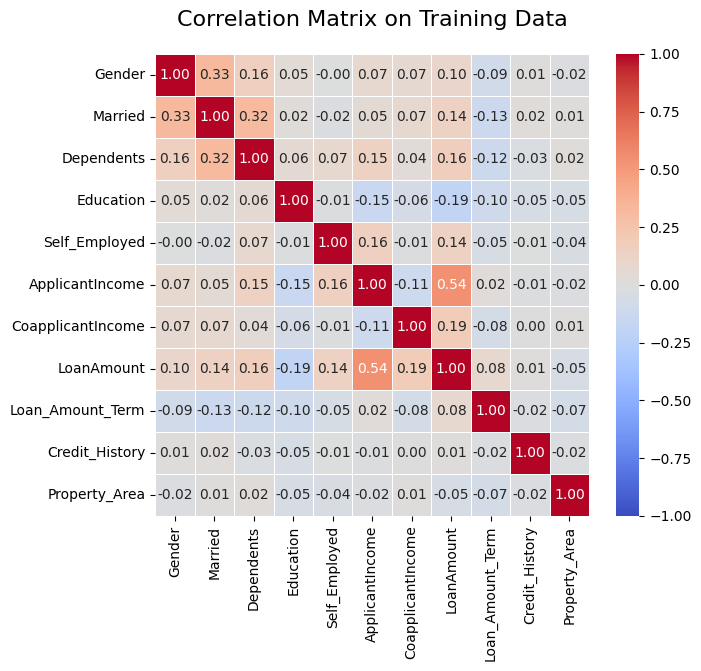

In [43]:
# 导入可视化库
import matplotlib.pyplot as plt
import seaborn as sns
# Seaborn 是一个基于 matplotlib 的高级可视化库，用于绘制更美观、更易理解的数据图表
import numpy as np


# 绘制热力图函数
def plot_correlation_matrix(data, title="Correlation Matrix"):
    plt.figure(figsize=(7, 6))

    # 计算相关矩阵
    corr_matrix = train_X.corr()

    # 生成上三角掩膜，避免重复显示
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # 绘制热力图
    sns.heatmap(corr_matrix,
                annot=True,       # 显示相关系数
                fmt=".2f",        # 保留两位小数
                cmap='coolwarm',  # 颜色映射
                vmin=-1, vmax=1,  # 数值范围
                linewidths=0.5,   # 单元格间距
                annot_kws={"size": 10})  # 注释字体大小

    # 设置标题
    plt.title(title, fontsize=16, pad=20)
    plt.show()

# 绘制训练集相关矩阵热力图
plot_correlation_matrix(train_X, title="Correlation Matrix on Training Data")

## **EX1.2 - Boruta算法和随机森林**
Boruta 是一种基于随机森林的特征选择算法。

目的： 自动选择对目标变量（标签）具有显著影响的特征。

特点：

不依赖特征缩放。

能够发现非线性和交互作用特征。

比传统的特征重要性方法（如feature_importances_）更稳健。



***特征选择***

In [44]:
!pip install boruta

In [45]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

In [47]:
# 初始化随机森林分类器
rf = RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=42)

In [48]:
# 初始化Boruta特征选择器
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

In [49]:
# 拟合Boruta特征选择
# 使用训练数据拟合Boruta模型，自动判断哪些特征是重要的，哪些是不重要的
boruta_selector.fit(train_X.values, train_y.values)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	1
Tentative: 	0
Rejected: 	10


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	0
Rejected: 	10


BorutaPy(estimator=RandomForestClassifier(max_depth=5, n_estimators=93,
                                          n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7A42BC3CE440),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7A42BC3CE440, verbose=2)

In [50]:
# 打印选择的特征
selected_features = train_X.columns[boruta_selector.support_]
print("Most important feature：", list(selected_features))

Most important feature： ['Credit_History']


Iteration: 1 / 100
Confirmed: 5 / 15
Tentative: 3 / 15
Rejected: 7 / 15

Confirmed： 被确认的重要特征数量。

Tentative： 暂定特征，需要进一步确认。

Rejected： 被拒特征，无显著影响。

## **EX1-3** 构建一个仅包涵这些特征的新的数据集并重新训练模型 **

In [51]:
X_boruta = data[selected_features]
y = data['Loan_Status']

# 重新划分训练集与测试集
train_X_b, test_X_b, train_y_b, test_y_b = train_test_split(X_boruta, y, test_size=0.2, random_state=42)

# 模型训练
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_X_b, train_y_b)


RandomForestClassifier(random_state=42)

**预测与评估**

In [52]:
from sklearn.metrics import accuracy_score, classification_report

preds_b = rf_model.predict(test_X_b)
print("Accuracy (Boruta features):", accuracy_score(test_y_b, preds_b))
print("\nClassification Report:\n", classification_report(test_y_b, preds_b))


Accuracy (Boruta features): 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



**对比完整数据集的模型 和 Boruta筛选后的模型**


In [69]:
X_full = data.drop(columns=['Loan_Status'])
y_full = data['Loan_Status']
train_X, test_X, train_y, test_y = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(train_X, train_y)

preds_full = rf_full.predict(test_X)
print("✅ Accuracy (Full features):", accuracy_score(test_y, preds_full))
print("\nClassification Report (Full):\n", classification_report(test_y, preds_full))

✅ Accuracy (Full features): 0.7560975609756098

Classification Report (Full):
               precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



# **EX2** 模型的可解释性 -- Explicabilité

Utiliser les Shap Value

<Figure size 640x480 with 0 Axes>

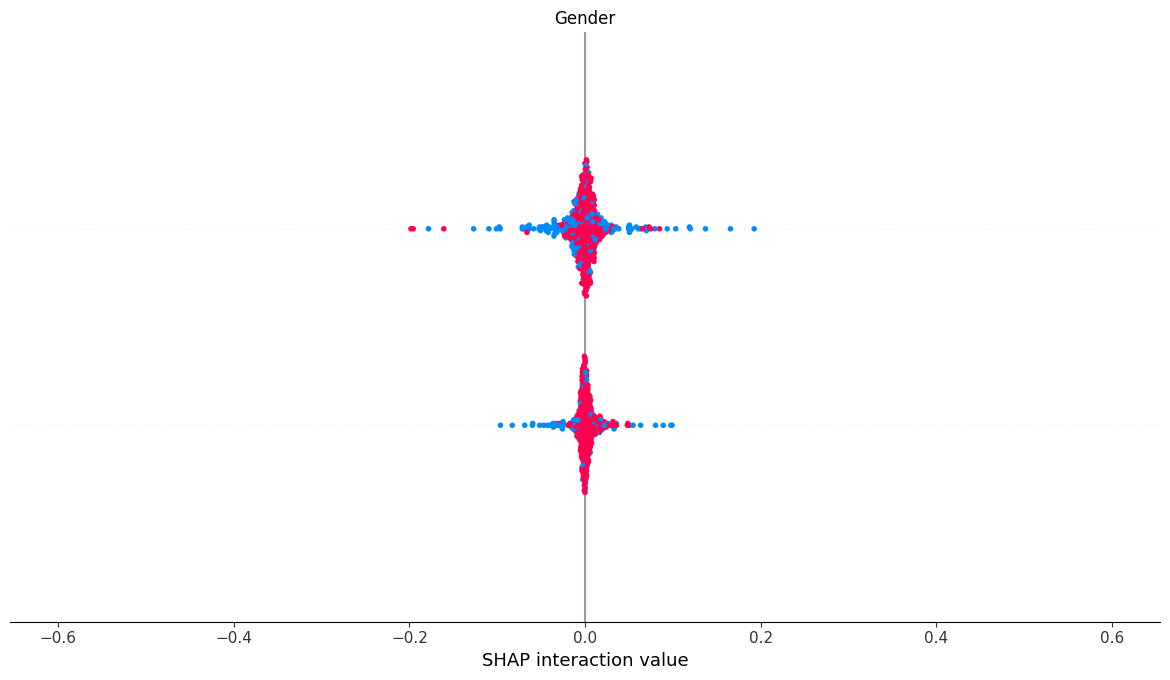

In [70]:
import shap

# 创建 SHAP explainer（使用概率输出更直观）
explainer = shap.TreeExplainer(full_model)

# 计算 SHAP 值，二分类任务返回两个类的值
shap_values = explainer.shap_values(train_X)

# 绘制 class_1 的 summary plot（贷款通过）
shap.summary_plot(shap_values,train_X)


# **ICE图**

In [66]:
!pip install -U scikit-learn

ValueError: cannot reshape array of size 1 into shape (2)

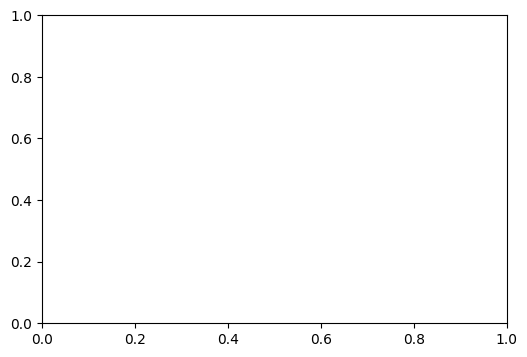

In [ ]:
from pdpbox import pdp
import matplotlib.pyplot as plt